# Feature Engineering III

**Transform to log of volatility**

Author: Pete King

During EDA (ref. notebook 5), we noticed that the historical volatility (feature) and future volatility (target) shared a log-linear relationship.  This transformation might improve our models' ability to learn the relationship between these important variables more quickly.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import data_prep as dp

DATA_DIR = Path.cwd().parent / 'data'
ETF_DATA_FILE = DATA_DIR / 'etf_transformed.csv'
TICKER = 'SPY'

In [2]:
etf_df = pd.read_csv(
    ETF_DATA_FILE,
    index_col='date',
    parse_dates=True
)
tickers_df = pd.read_csv(DATA_DIR / 'tickers.csv')
tickers = list(tickers_df['Tickers'])

Let's quickly recreate what we found during EDA to show the log-linear relationship.

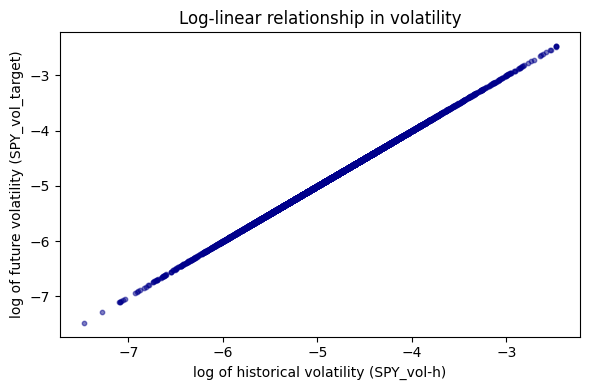

In [3]:
# Variables to be plotted
x = TICKER + '_vol-h'
y = TICKER + '_vol_target'

fig = plt.figure(figsize=(6, 4))
ax = fig.subplots()
ax.set_title(f'Log-linear relationship in volatility')
ax.set_xlabel('log of historical volatility (' + x + ')')
ax.set_ylabel('log of future volatility (' + y + ')')
ax.scatter(
    etf_df[x].apply(np.log),
    etf_df[x].apply(np.log),
    s=10, c='#00008B', alpha=0.5
)
fig.tight_layout()

We now apply the log transformation and save the additional features and labels.

In [4]:
etf_logvol_h, etf_logvol_tgt = {}, {}
for ticker in tickers:
    etf_logvol_h[ticker + '_log_vol-h'] = etf_df[ticker + '_vol-h'].apply(np.log)
    etf_logvol_tgt[ticker + '_log_vol_target'] = etf_df[ticker + '_vol_target'].apply(np.log)

In [5]:
etf_log_df = pd.concat(
    [etf_df, pd.DataFrame(etf_logvol_h), pd.DataFrame(etf_logvol_tgt)],
    axis=1
)
etf_log_df

,BIL_ret,BND_ret,GLD_ret,HYG_ret,IEF_ret,IWM_ret,LQD_ret,QQQ_ret,SPY_ret,TIP_ret,...,XLB_log_vol_target,XLE_log_vol_target,XLF_log_vol_target,XLI_log_vol_target,XLK_log_vol_target,XLP_log_vol_target,XLRE_log_vol_target,XLU_log_vol_target,XLV_log_vol_target,XLY_log_vol_target
date,,,,,,,,,,,,,,,,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.007087,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002116,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010515,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004176,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-09,0.000109,0.000407,0.007748,0.001122,-0.000314,0.005704,0.000000,0.006742,0.005753,0.000451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-10,0.000328,-0.001493,-0.001783,-0.003994,-0.001678,-0.002523,-0.002652,0.001441,-0.000662,0.000541,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-13,0.000000,0.002170,-0.004057,0.003745,0.002202,0.014325,0.003839,0.010289,0.009725,0.002339,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


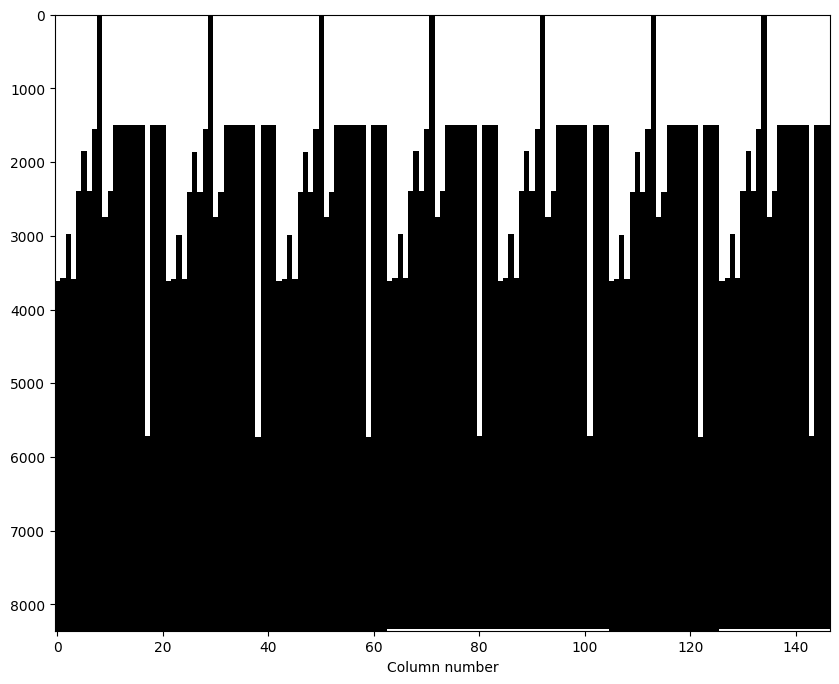

In [6]:
dp.view_nan(etf_log_df);

In [7]:
etf_log_df.to_csv(DATA_DIR / 'etf_transformed_log.csv', index_label='date')